# Bike Classic ML


This Model: 
1. Answers: RQ1: Can the graph-aware non-GNN baselines predict the attractiveness of census tract in Toronto for cyclists?
2. Help building the fixed pipeline used for the rest of the models
3. Deduct features and importance? which feature could cause overfitting?

In [1]:
print("Najla")

Najla


In [46]:
import sys

project_root = "/home/najla/dev/najla-msc/bikeshare"

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root:", project_root)

Project root: /home/najla/dev/najla-msc/bikeshare


In [47]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import networkx as nx
from node2vec import Node2Vec
import numpy as np
from catboost import CatBoostRegressor, Pool, metrics, cv
from sklearn.metrics import accuracy_score
from scripts.model_helper import BikeShareModelHelper as mh

In [48]:
# read the data
dir = Path("/home/najla/dev/najla-msc/bikeshare/data/")
wikidata_loc = pd.read_parquet(dir / "processed/bike_ridership/wikidata_loc_5yrs_12pm.parquet")
wikidata_loc.head(5)

,itemLabel,instanceOfLabel,loc_id
0,1 Spadina Crescent,university building,5350061.00
1,10 Dundas East,"building complex, entertainment venue, shoppin...",5350034.02
2,10 Navy,skyscraper,5350012.03
3,"121 St. George Street, Toronto",university building,5350061.00
4,"123 Edward Street, Toronto",university building,5350035.00


In [49]:
wikidata_loc.shape

(2251, 3)

In [50]:
# filter out the broken node from the data
static_features = pd.read_parquet(dir / "processed/bike_ridership/static_features_5yrs_12pm.parquet")
# This CT is the island / disconnected node.
# It has no graph neighbours, so it breaks the connected Toronto graph.
island_loc_id = '5350002.00'

# Remove the island node from static features.
static_features = (
    static_features
    .loc[static_features["loc_id"] != island_loc_id]
    .reset_index(drop=True)
)
static_features.head(5)

,loc_id,loc_name,lon,lat,population,jobs,area,poi_arts_and_entertainment,poi_community_and_government,poi_cultural_and_historic,...,land_use_recreation,land_use_religious,land_use_residential,land_use_resource_extraction,land_use_transportation,land_use_winter_sports,stations_capacity_sum,start_stations_count,end_stations_count,total_stations
0,5320100.01,0100.01,-78.935020,43.856672,0.000451,0.000203,16220000.0,4.637299e-07,1.391190e-06,6.376286e-07,...,0.000218,0.000000,0.012452,0.000000,0.001572,0.0,NaN,NaN,NaN,NaN
1,5320100.02,0100.02,-78.966386,43.869987,0.002052,0.000875,2680000.0,3.708509e-07,3.708509e-07,3.708509e-07,...,0.000587,0.000000,0.134664,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN
2,5320100.03,0100.03,-78.972803,43.882699,0.001365,0.000666,5940000.0,3.367461e-07,3.367461e-07,6.734923e-07,...,0.000423,0.002103,0.041123,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN
3,5320105.14,0105.14,-78.985482,43.927658,0.000334,0.000157,15920000.0,1.250645e-07,3.126613e-07,1.250645e-07,...,0.000069,0.000000,0.017175,0.024266,0.000000,0.0,NaN,NaN,NaN,NaN
4,5320105.17,0105.17,-78.992870,43.987493,0.000032,0.000016,52030000.0,3.834821e-08,1.342188e-07,1.150446e-07,...,0.000019,0.001239,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN


In [51]:
static_features.shape

(1247, 46)

In [52]:
static_features.columns

Index(['loc_id', 'loc_name', 'lon', 'lat', 'population', 'jobs', 'area',
       'poi_arts_and_entertainment', 'poi_community_and_government',
       'poi_cultural_and_historic', 'poi_education', 'poi_food_and_drink',
       'poi_geographic_entities', 'poi_health_care', 'poi_lifestyle_services',
       'poi_lodging', 'poi_services_and_business', 'poi_shopping',
       'poi_sports_and_recreation', 'poi_travel_and_transportation',
       'land_use_agriculture', 'land_use_campground', 'land_use_cemetery',
       'land_use_construction', 'land_use_developed', 'land_use_education',
       'land_use_entertainment', 'land_use_golf', 'land_use_horticulture',
       'land_use_landfill', 'land_use_managed', 'land_use_medical',
       'land_use_military', 'land_use_park', 'land_use_pedestrian',
       'land_use_protected', 'land_use_recreation', 'land_use_religious',
       'land_use_residential', 'land_use_resource_extraction',
       'land_use_transportation', 'land_use_winter_sports',
       's

In [53]:
dynamic_features = pd.read_parquet(dir / "processed/bike_ridership/dynamic_features_5yrs_12pm.parquet")
dynamic_features.head(5)

,date,day_type,public_holiday,weather_category,season
0,2022-01-01,weekend,new_years_day,snowy,winter
1,2022-01-02,weekend,no_public_holiday,snowy,winter
2,2022-01-03,weekday,no_public_holiday,very_cold,winter
3,2022-01-04,weekday,no_public_holiday,very_cold,winter
4,2022-01-05,weekday,no_public_holiday,windy,winter


In [54]:
# prepare label_1 label_2 ... etc.
wikidata_clean = wikidata_loc.copy()

wikidata_clean["label_instance"] = (
    wikidata_clean["instanceOfLabel"]
    .fillna("")
    .str.split(",")
    .apply(
        lambda labels: " ".join(
            label.strip().replace(" ", "_")
            for label in labels
            if label.strip()
        )
    )
)

wikidata_clean.head(5)

,itemLabel,instanceOfLabel,loc_id,label_instance
0,1 Spadina Crescent,university building,5350061.00,university_building
1,10 Dundas East,"building complex, entertainment venue, shoppin...",5350034.02,building_complex entertainment_venue shopping_...
2,10 Navy,skyscraper,5350012.03,skyscraper
3,"121 St. George Street, Toronto",university building,5350061.00,university_building
4,"123 Edward Street, Toronto",university building,5350035.00,university_building


In [55]:
wikidata_clean = wikidata_clean.groupby("loc_id") \
    .agg(
        attraction_count=("itemLabel", "count"),
        wiki_items_text=(
            "label_instance",
            lambda x: " ".join(sorted(set(x.dropna().astype(str))))
        )
    ).reset_index()
wikidata_clean.head(5)

,loc_id,attraction_count,wiki_items_text
0,5350001.00,13,artificial_island bay beach building bus_garag...
1,5350002.00,23,airport commercial_traffic_aerodrome airport_...
2,5350003.00,7,changing_room pavilion filling_station monumen...
3,5350004.00,4,destroyed_building_or_structure movie_theater ...
4,5350005.00,10,Catholic_seminary Little_Tibet neighborhood ca...


In [56]:
#safe for later use by graph
graph_path = Path("/home/najla/dev/najla-msc/bikeshare/data/processed/graph")
#wikidata_clean.to_parquet(graph_path / "all_wikidata_tokens.parquet", index=False)

In [57]:
# read the data
edges = pd.read_parquet(graph_path / "edges.parquet").reset_index()
edges.head(5)

,level_0,level_1,weight,geometry
0,5320100.01,5350805.21,5229.881836,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\x17\x9c...
1,5320100.01,5320100.02,2923.277907,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\x17\x9c...
2,5320100.01,5350805.04,4516.007185,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\x17\x9c...
3,5320100.02,5350805.21,2780.244458,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\xa8\x05...
4,5320100.02,5350805.23,3346.251980,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\xa8\x05...


In [58]:
# Keep the original edge distance in a clear column.
# edges["weight"] should represent distance in meters.
edges["distance_m"] = edges["weight"]

# Convert distance to proximity.
# Smaller distance = larger affinity weight.
# The small 1e-6 avoids division by zero.
edges["affinity_weight"] = 1 / (edges["distance_m"] + 1e-6)

# Build a graph from the edge dataframe.
# source and target are the two connected CT/location IDs.
# affinity_weight is stored as an edge attribute.
G = nx.from_pandas_edgelist(
    edges,
    source="level_0",
    target="level_1",
    edge_attr="affinity_weight"
)

# =====================================================> subject to change base on catboost performance
# Create Node2Vec random walks.
# q=2.0 keeps walks more local, which is useful for nearby CT similarity.
node2vec = Node2Vec(
    G,
    dimensions=16,              # creates 16, 32 embedding features per node
    walk_length=10,             # each random walk has 10 steps
    num_walks=50,               # creates 50 walks from each node
    p=1.0,                      # neutral backtracking behavior
    q=2.0,                      # q > 1 keeps walks local/neighborhood-focused
    weight_key="affinity_weight", # closer nodes are visited more often
    workers=4,                  # use 4 CPU workers
    seed=42                     # reproducible random walks
)

# Train the embedding model from the generated walks.
model = node2vec.fit(
    window=5,                   # nodes within 5 steps in a walk are related
    min_count=1                 # keep every node in the graph
)

# Extract one embedding vector per graph node.
embeddings = []

for node in G.nodes():
    vector = model.wv[str(node)]

    row = {"loc_id": node}

    for i, value in enumerate(vector):
        row[f"node2vec_{i}"] = value

    embeddings.append(row)

# Convert embeddings into a dataframe for merging with your main features.
node2vec_features = pd.DataFrame(embeddings)

node2vec_features.head(5)

Computing transition probabilities:   0%|          | 0/1247 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 12/12 [00:00<00:00, 26.85it/s]


,loc_id,node2vec_0,node2vec_1,node2vec_2,node2vec_3,node2vec_4,node2vec_5,node2vec_6,node2vec_7,node2vec_8,node2vec_9,node2vec_10,node2vec_11,node2vec_12,node2vec_13,node2vec_14,node2vec_15
0,5320100.01,0.949989,-1.147531,0.676582,2.218529,0.712883,-1.209347,0.426974,-0.601783,-0.330492,0.686196,0.014312,0.825249,-1.001501,-2.237725,-0.825952,0.695551
1,5350805.21,0.819470,-0.905411,0.473085,2.305227,1.501894,-1.081070,0.103762,-0.731762,-0.536530,0.874180,0.199632,0.967680,-1.403705,-2.583159,-0.976340,0.901399
2,5320100.02,1.231880,-1.230457,0.459385,2.355333,0.928196,-1.491176,0.076405,-0.467300,-0.344609,0.717802,-0.010819,0.919059,-1.268076,-2.592594,-0.740861,1.105326
3,5350805.04,0.997211,-1.319718,0.855310,2.573683,0.938912,-1.129897,0.643461,-0.871308,-0.738228,1.105701,0.038364,0.700059,-1.172874,-2.197915,-0.797342,0.415215
4,5350805.23,0.790751,-0.786955,0.206515,2.228498,1.437095,-1.364865,-0.540171,-0.394034,-0.604379,0.969270,-0.108482,1.330804,-1.456812,-2.436085,-0.425777,1.456524


In [59]:
node2vec_features.shape

(1247, 17)

In [60]:
embedding_cols = [c for c in node2vec_features.columns if c.startswith("node2vec_")]

# Number of nodes sharing an identical embedding vector
node2vec_features.duplicated(subset=embedding_cols).sum()

np.int64(0)

In [61]:
# read inflow
# read outflow
inflow = pd.read_parquet(dir / "processed/bike_ridership/inflow_5yrs_12pm.parquet")
inflow.head(5)

,date,end_station_name,end_loc_id,end_capacity_avg,end_trips_count
0,2022-01-01,111 Bond St (North of Dundas St E) - SMART,5350034.02,16.0,2
1,2022-01-01,1303 Yonge St - SMART,5350124.00,15.0,1
2,2022-01-01,161 Bleecker St (South of Wellesley),5350066.00,23.0,1
3,2022-01-01,25 Booth Ave,5350001.00,24.0,2
4,2022-01-01,25 York St – Union Station South,5350013.01,11.0,1


In [62]:
inflow.shape

(666381, 5)

In [63]:
outflow = pd.read_parquet(dir / "processed/bike_ridership/outflow_5yrs_12pm.parquet")
outflow.head(5)

,date,start_station_name,start_loc_id,start_capacity_avg,start_trips_count
0,2022-01-01,12 Harbour St,5350013.02,15.0,2
1,2022-01-01,1303 Yonge St - SMART,5350124.00,15.0,1
2,2022-01-01,161 Bleecker St (South of Wellesley),5350066.00,23.0,1
3,2022-01-01,190 Queens Quay E,5350017.02,15.0,2
4,2022-01-01,25 Booth Ave,5350001.00,24.0,1


Datafram Prep For Catboost

In [64]:
outflow.shape

(692609, 5)

In [65]:
# 
inflow_station = inflow.rename(
    columns={
        "end_loc_id": "loc_id",
        "end_station_name": "station_name",
        "end_capacity_avg": "station_capacity_avg",
        "end_trips_count": "inflow_count",
    }
)

outflow_station = outflow.rename(
    columns={
        "start_loc_id": "loc_id",
        "start_station_name": "station_name",
        "start_capacity_avg": "station_capacity_avg",
        "start_trips_count": "outflow_count",
    }
)

flow_station = pd.concat(
    [inflow_station, outflow_station],
    ignore_index=True,
)

flow_station["loc_id"] = flow_station["loc_id"].astype(str)
flow_station["date"] = pd.to_datetime(flow_station["date"])

flow_station = (
    flow_station
    .groupby(["loc_id", "date", "station_name"], as_index=False)
    .agg(
        station_capacity_avg=("station_capacity_avg", "mean"),
        inflow_count=("inflow_count", "sum"),
        outflow_count=("outflow_count", "sum"),
    )
)

flow_station["inflow_count"] = flow_station["inflow_count"].fillna(0)
flow_station["outflow_count"] = flow_station["outflow_count"].fillna(0)

In [66]:
# -----------------------------
# Prepare join tables
# -----------------------------

static_join = static_features.copy()
wiki_join = wikidata_clean.copy()
graph_join = node2vec_features.copy()
dynamic_join = dynamic_features.copy()

for df_ in [static_join, wiki_join, graph_join]:
    df_["loc_id"] = df_["loc_id"].astype(str)

dynamic_join["date"] = pd.to_datetime(dynamic_join["date"])

dynamic_join = dynamic_join.rename(
    columns={"weather_category": "Main_Weather_Category"}
)

df_prep = (
    static_join
    .merge(flow_station, on="loc_id", how="left")
    .merge(wiki_join, on="loc_id", how="left")
    .merge(graph_join, on="loc_id", how="left")
    .merge(dynamic_join, on="date", how="left")
).drop_duplicates()

In [67]:
df_prep.shape

(741389, 73)

In [68]:
df_prep.head(100)

,loc_id,loc_name,lon,lat,population,jobs,area,poi_arts_and_entertainment,poi_community_and_government,poi_cultural_and_historic,...,node2vec_10,node2vec_11,node2vec_12,node2vec_13,node2vec_14,node2vec_15,day_type,public_holiday,Main_Weather_Category,season
0,5320100.01,0100.01,-78.935020,43.856672,0.000451,0.000203,16220000.0,4.637299e-07,1.391190e-06,6.376286e-07,...,0.014312,0.825249,-1.001501,-2.237725,-0.825952,0.695551,NaN,NaN,NaN,NaN
1,5320100.02,0100.02,-78.966386,43.869987,0.002052,0.000875,2680000.0,3.708509e-07,3.708509e-07,3.708509e-07,...,-0.010819,0.919059,-1.268076,-2.592594,-0.740861,1.105326,NaN,NaN,NaN,NaN
2,5320100.03,0100.03,-78.972803,43.882699,0.001365,0.000666,5940000.0,3.367461e-07,3.367461e-07,6.734923e-07,...,0.098712,1.385985,-1.433188,-2.331979,-0.772997,1.491132,NaN,NaN,NaN,NaN
3,5320105.14,0105.14,-78.985482,43.927658,0.000334,0.000157,15920000.0,1.250645e-07,3.126613e-07,1.250645e-07,...,0.078293,2.241579,-1.623576,-0.713119,-0.455179,1.686906,NaN,NaN,NaN,NaN
4,5320105.17,0105.17,-78.992870,43.987493,0.000032,0.000016,52030000.0,3.834821e-08,1.342188e-07,1.150446e-07,...,0.041566,2.199095,-1.402957,-0.124912,-0.467859,1.229893,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5350001.00,0001.00,-79.334142,43.646019,0.000088,0.000055,6820000.0,3.780645e-06,2.035732e-06,5.816377e-07,...,0.118118,0.434102,1.381410,-2.212004,1.429404,1.111674,weekday,no_public_holiday,snowy,winter
96,5350001.00,0001.00,-79.334142,43.646019,0.000088,0.000055,6820000.0,3.780645e-06,2.035732e-06,5.816377e-07,...,0.118118,0.434102,1.381410,-2.212004,1.429404,1.111674,weekday,no_public_holiday,snowy,winter
97,5350001.00,0001.00,-79.334142,43.646019,0.000088,0.000055,6820000.0,3.780645e-06,2.035732e-06,5.816377e-07,...,0.118118,0.434102,1.381410,-2.212004,1.429404,1.111674,weekday,no_public_holiday,snowy,winter
98,5350001.00,0001.00,-79.334142,43.646019,0.000088,0.000055,6820000.0,3.780645e-06,2.035732e-06,5.816377e-07,...,0.118118,0.434102,1.381410,-2.212004,1.429404,1.111674,weekday,no_public_holiday,snowy,winter


In [69]:
df_prep.columns

Index(['loc_id', 'loc_name', 'lon', 'lat', 'population', 'jobs', 'area',
       'poi_arts_and_entertainment', 'poi_community_and_government',
       'poi_cultural_and_historic', 'poi_education', 'poi_food_and_drink',
       'poi_geographic_entities', 'poi_health_care', 'poi_lifestyle_services',
       'poi_lodging', 'poi_services_and_business', 'poi_shopping',
       'poi_sports_and_recreation', 'poi_travel_and_transportation',
       'land_use_agriculture', 'land_use_campground', 'land_use_cemetery',
       'land_use_construction', 'land_use_developed', 'land_use_education',
       'land_use_entertainment', 'land_use_golf', 'land_use_horticulture',
       'land_use_landfill', 'land_use_managed', 'land_use_medical',
       'land_use_military', 'land_use_park', 'land_use_pedestrian',
       'land_use_protected', 'land_use_recreation', 'land_use_religious',
       'land_use_residential', 'land_use_resource_extraction',
       'land_use_transportation', 'land_use_winter_sports',
       's

In [70]:
# filter out rows where both target columns are NaN
df_prep = df_prep.loc[
    ~(
        df_prep["inflow_count"].isna()
        & df_prep["outflow_count"].isna()
    )
].copy()

In [71]:
df_prep.shape

(740505, 73)

In [72]:
df_prep.shape

(740505, 73)

In [73]:
# test
df_prep["wiki_items_text"].isnull().sum(axis=0)

np.int64(33069)

In [74]:
# clean the text
df_prep["wiki_items_text"] = (
    df_prep["wiki_items_text"]
    .fillna("no_wiki_data")
    .astype(str)
)

In [75]:
df_prep.columns

Index(['loc_id', 'loc_name', 'lon', 'lat', 'population', 'jobs', 'area',
       'poi_arts_and_entertainment', 'poi_community_and_government',
       'poi_cultural_and_historic', 'poi_education', 'poi_food_and_drink',
       'poi_geographic_entities', 'poi_health_care', 'poi_lifestyle_services',
       'poi_lodging', 'poi_services_and_business', 'poi_shopping',
       'poi_sports_and_recreation', 'poi_travel_and_transportation',
       'land_use_agriculture', 'land_use_campground', 'land_use_cemetery',
       'land_use_construction', 'land_use_developed', 'land_use_education',
       'land_use_entertainment', 'land_use_golf', 'land_use_horticulture',
       'land_use_landfill', 'land_use_managed', 'land_use_medical',
       'land_use_military', 'land_use_park', 'land_use_pedestrian',
       'land_use_protected', 'land_use_recreation', 'land_use_religious',
       'land_use_residential', 'land_use_resource_extraction',
       'land_use_transportation', 'land_use_winter_sports',
       's

In [76]:
import pandas as pd
import geopandas as gpd
from sklearn.cluster import KMeans

df = df_prep.copy()

df["loc_id_key"] = df["loc_id"].astype(float).map(
    lambda x: f"{x:010.2f}"
)

ct_centers = (
    df[["loc_id", "loc_id_key", "lat", "lon"]]
    .dropna(subset=["lat", "lon"])
    .drop_duplicates(subset=["loc_id_key"])
    .copy()
)

# =========================
# 4. Project centroid points
# =========================

ct_centers = gpd.GeoDataFrame(
    ct_centers,
    geometry=gpd.points_from_xy(ct_centers["lon"], ct_centers["lat"]),
    crs="EPSG:4326"
)

ct_centers = ct_centers.to_crs(epsg=26917)

ct_centers["x"] = ct_centers.geometry.x
ct_centers["y"] = ct_centers.geometry.y

# =========================
# 5. Predict 10 spatial clusters
# =========================

kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=10
)

ct_centers["spatial_group"] = kmeans.fit_predict(
    ct_centers[["x", "y"]]
)

# =========================
# 6. Merge cluster number back to df
# =========================

df = df.merge(
    ct_centers[["loc_id_key", "spatial_group"]],
    on="loc_id_key",
    how="left"
)

# =========================
# 7. Check CT count per cluster
# =========================

df[["loc_id", "spatial_group"]].drop_duplicates() \
    .groupby("spatial_group")["loc_id"].nunique() \
    .sort_values()

spatial_group
17     8
14     9
9     13
3     13
16    13
11    14
8     14
0     15
2     15
4     18
7     18
12    19
6     20
5     21
15    22
10    22
18    22
19    26
13    29
1     32
Name: loc_id, dtype: int64

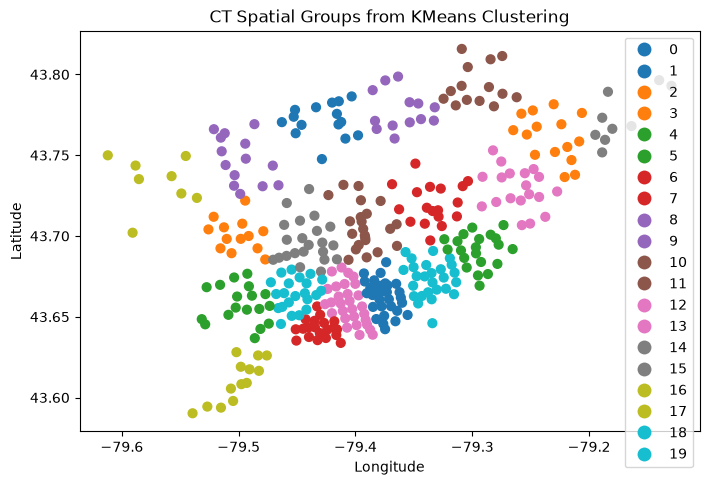

In [77]:
import matplotlib.pyplot as plt

plot_gdf = ct_centers.to_crs(epsg=4326)

ax = plot_gdf.plot(
    column="spatial_group",
    categorical=True,
    legend=True,
    figsize=(8, 8),
    markersize=40
)

ax.set_title("CT Spatial Groups from KMeans Clustering")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [78]:
import folium

# Use one row per CT
map_df = ct_centers[["end_loc_id", "lat", "lon", "spatial_group"]].copy()

# Create map centered on Toronto CTs
m = folium.Map(
    location=[map_df["lat"].mean(), map_df["lon"].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

# Colour list for 10 clusters
colors = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "lightblue", "darkgreen", "cadetblue", "pink"
]

# Add CT centroid points
for _, row in map_df.iterrows():
    group = int(row["spatial_group"])
    
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=colors[group],
        fill=True,
        fill_color=colors[group],
        fill_opacity=0.8,
        popup=f"CT: {row['end_loc_id']}<br>Cluster: {group}"
    ).add_to(m)
m.save("/home/najla/dev/najla-msc/bikeshare/results/semantic_embedings_test/catboost/ct_spatial_groups_map.html")

KeyError: "['end_loc_id'] not in index"

In [79]:
df.columns

Index(['loc_id', 'loc_name', 'lon', 'lat', 'population', 'jobs', 'area',
       'poi_arts_and_entertainment', 'poi_community_and_government',
       'poi_cultural_and_historic', 'poi_education', 'poi_food_and_drink',
       'poi_geographic_entities', 'poi_health_care', 'poi_lifestyle_services',
       'poi_lodging', 'poi_services_and_business', 'poi_shopping',
       'poi_sports_and_recreation', 'poi_travel_and_transportation',
       'land_use_agriculture', 'land_use_campground', 'land_use_cemetery',
       'land_use_construction', 'land_use_developed', 'land_use_education',
       'land_use_entertainment', 'land_use_golf', 'land_use_horticulture',
       'land_use_landfill', 'land_use_managed', 'land_use_medical',
       'land_use_military', 'land_use_park', 'land_use_pedestrian',
       'land_use_protected', 'land_use_recreation', 'land_use_religious',
       'land_use_residential', 'land_use_resource_extraction',
       'land_use_transportation', 'land_use_winter_sports',
       's

In [81]:
node2vec_cols = [c for c in df.columns if c.startswith("node2vec_")]
df = df.dropna(subset=node2vec_cols)


# Standardize the missing Wikidata text label.
df["wiki_items_text"] = (
    df["wiki_items_text"]
    .fillna("no_wikidata")
    .replace({"no_wiki_data": "no_wikidata"})
)

# Mark attraction_count as missing if it is NaN, already -1, or has no Wikidata text.
df["attraction_missing_flag"] = (
    df["attraction_count"].isna()
    | df["attraction_count"].eq(-1)
    | df["wiki_items_text"].eq("no_wikidata")
).astype(int)

# Keep -1 as the numeric sentinel for missing attraction_count.
df.loc[df["attraction_missing_flag"].eq(1), "attraction_count"] = -1


df["total_stations"] = df["total_stations"].fillna(df["end_stations_count"])

df["outflow_count"] = df["outflow_count"].fillna(0)
df["inflow_count"] = df["inflow_count"].fillna(0)

In [82]:
# check for missing values in key columns
df[
    [
        "station_name",
        "station_capacity_avg",
        "inflow_count",
        "outflow_count",
        "attraction_count",
        "attraction_missing_flag",
    ]
].isna().sum()

station_name               0
station_capacity_avg       0
inflow_count               0
outflow_count              0
attraction_count           0
attraction_missing_flag    0
dtype: int64

In [83]:
df = df.drop(columns=['start_stations_count', 'end_stations_count', 'loc_id_key'])

In [84]:
df.columns

Index(['loc_id', 'loc_name', 'lon', 'lat', 'population', 'jobs', 'area',
       'poi_arts_and_entertainment', 'poi_community_and_government',
       'poi_cultural_and_historic', 'poi_education', 'poi_food_and_drink',
       'poi_geographic_entities', 'poi_health_care', 'poi_lifestyle_services',
       'poi_lodging', 'poi_services_and_business', 'poi_shopping',
       'poi_sports_and_recreation', 'poi_travel_and_transportation',
       'land_use_agriculture', 'land_use_campground', 'land_use_cemetery',
       'land_use_construction', 'land_use_developed', 'land_use_education',
       'land_use_entertainment', 'land_use_golf', 'land_use_horticulture',
       'land_use_landfill', 'land_use_managed', 'land_use_medical',
       'land_use_military', 'land_use_park', 'land_use_pedestrian',
       'land_use_protected', 'land_use_recreation', 'land_use_religious',
       'land_use_residential', 'land_use_resource_extraction',
       'land_use_transportation', 'land_use_winter_sports',
       's

In [85]:
import numpy as np
import pandas as pd
import gc

# clear all other variables except df
# Keep df and clear normal user variables only

# repair IPython output-history variable if it was deleted
ip = get_ipython()

if "_oh" not in ip.user_ns:
    ip.user_ns["_oh"] = {}

ip.user_ns["Out"] = ip.user_ns["_oh"]


# keep only df and IPython internals
_keep_names = {
    "df",
    "In",
    "Out",
    "get_ipython",
    "exit",
    "quit",
    "ip",
    "_keep_names",
    "_name",
}

for _name in list(globals().keys()):
    if _name in _keep_names:
        continue

    if _name.startswith("_"):
        continue

    del globals()[_name]


# do NOT clear Out now; it is what caused the _oh issue
import gc
gc.collect()

10518

In [86]:
[name for name in globals().keys() if not name.startswith("_")][:50]

['In', 'Out', 'get_ipython', 'exit', 'quit', 'df', 'ip', 'gc']

In [87]:
import numpy as np
import pandas as pd
import gc
def make_row_balanced_spatial_folds(
    df,
    group_col="spatial_group",
    n_folds=10,
    n_test_groups=3,
    n_val_groups=3,
    seed=42,
    n_candidates=20000,
):
    group_counts = df.groupby(group_col).size()
    groups = group_counts.index.to_numpy()
    total_rows = len(df)

    fold_specs = []
    seen_splits = set()
    rng = np.random.default_rng(seed)

    for fold_id in range(n_folds):
        best = None
        best_score = np.inf

        for _ in range(n_candidates):
            shuffled = rng.permutation(groups)

            test_groups = tuple(sorted(shuffled[:n_test_groups]))
            val_groups = tuple(
                sorted(shuffled[n_test_groups:n_test_groups + n_val_groups])
            )
            train_groups = tuple(
                sorted(shuffled[n_test_groups + n_val_groups:])
            )

            split_key = (train_groups, val_groups, test_groups)

            if split_key in seen_splits:
                continue

            train_rows = group_counts.loc[list(train_groups)].sum()
            val_rows = group_counts.loc[list(val_groups)].sum()
            test_rows = group_counts.loc[list(test_groups)].sum()

            train_pct = train_rows / total_rows
            val_pct = val_rows / total_rows
            test_pct = test_rows / total_rows

            score = (
                abs(train_pct - 0.70)
                + abs(val_pct - 0.15)
                + abs(test_pct - 0.15)
            )

            if score < best_score:
                best_score = score
                best = {
                    "fold_id": fold_id,
                    "train_groups": train_groups,
                    "val_groups": val_groups,
                    "test_groups": test_groups,
                    "train_rows": train_rows,
                    "val_rows": val_rows,
                    "test_rows": test_rows,
                    "train_pct": train_pct,
                    "val_pct": val_pct,
                    "test_pct": test_pct,
                }

        seen_splits.add(
            (
                best["train_groups"],
                best["val_groups"],
                best["test_groups"],
            )
        )

        fold_specs.append(best)

    return fold_specs

In [88]:
# =========================================================
# Convert fold_specs into a reusable fold-assignment table
# =========================================================

# Each row records:
#   1. which spatial CV fold it belongs to;
#   2. which spatial group it describes;
#   3. whether that group is train, validation or test.

fold_specs = make_row_balanced_spatial_folds(
    df,
    group_col="spatial_group",
    n_folds=10,
    n_test_groups=3,
    n_val_groups=3,
    seed=42,
)



fold_assignment_rows = []


# Process each spatial cross-validation fold.
for spec in fold_specs:

    # Read the current fold number.
    fold_id = spec["fold_id"]


    # -----------------------------------------------------
    # Store training spatial groups
    # -----------------------------------------------------

    for spatial_group in spec["train_groups"]:

        fold_assignment_rows.append(
            {
                "fold_id": fold_id,
                "spatial_group": spatial_group,
                "split": "train",
            }
        )


    # -----------------------------------------------------
    # Store validation spatial groups
    # -----------------------------------------------------

    for spatial_group in spec["val_groups"]:

        fold_assignment_rows.append(
            {
                "fold_id": fold_id,
                "spatial_group": spatial_group,
                "split": "val",
            }
        )


    # -----------------------------------------------------
    # Store test spatial groups
    # -----------------------------------------------------

    for spatial_group in spec["test_groups"]:

        fold_assignment_rows.append(
            {
                "fold_id": fold_id,
                "spatial_group": spatial_group,
                "split": "test",
            }
        )


# Convert the collected dictionaries into a dataframe.
fold_assignments_df = pd.DataFrame(
    fold_assignment_rows
)


# Sort the table so it is easy to inspect.
fold_assignments_df = (
    fold_assignments_df
    .sort_values(
        [
            "fold_id",
            "split",
            "spatial_group",
        ]
    )
    .reset_index(drop=True)
)


# Display the first rows.
fold_assignments_df.head(20)

,fold_id,spatial_group,split
0,0,0,test
1,0,5,test
2,0,19,test
3,0,1,train
4,0,2,train
5,0,3,train
6,0,7,train
7,0,8,train
8,0,9,train
9,0,10,train


In [89]:
# =========================================================
# Sanity check: Wikidata missingness must be consistent
# =========================================================

# A node has no Wikidata if wiki_items_text is one of the missing text labels.
no_wikidata_mask = (
    df["wiki_items_text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(
        [
            "no_wikidata",
            "no_wiki_data",
        ]
    )
)

# A node has missing attraction count if attraction_count was filled with -1.
missing_attraction_count_mask = df["attraction_count"].eq(-1)

# A node has missing attraction flag if attraction_missing_flag is 1.
missing_attraction_flag_mask = df["attraction_missing_flag"].eq(1)
# Count distinct CT nodes in each missingness group.
n_no_wikidata = df.loc[no_wikidata_mask, "loc_id"].nunique()
n_missing_attraction_count = df.loc[missing_attraction_count_mask, "loc_id"].nunique()
n_missing_attraction_flag = df.loc[missing_attraction_flag_mask, "loc_id"].nunique()

# Print the three counts. These should be the same.
print("Nodes with no Wikidata:", n_no_wikidata)
print("Nodes with attraction_count = -1:", n_missing_attraction_count)
print("Nodes with attraction_missing_flag = 1:", n_missing_attraction_flag)

# Check whether the three node sets are exactly the same, not only the same size.
no_wikidata_nodes = set(df.loc[no_wikidata_mask, "loc_id"].unique())
missing_attraction_count_nodes = set(df.loc[missing_attraction_count_mask, "loc_id"].unique())
missing_attraction_flag_nodes = set(df.loc[missing_attraction_flag_mask, "loc_id"].unique())

print(
    "Same node sets:",
    no_wikidata_nodes
    == missing_attraction_count_nodes
    == missing_attraction_flag_nodes
)

# Stop the notebook if the three groups are not exactly equal.
assert no_wikidata_nodes == missing_attraction_count_nodes == missing_attraction_flag_nodes

Nodes with no Wikidata: 59
Nodes with attraction_count = -1: 59
Nodes with attraction_missing_flag = 1: 59
Same node sets: True


In [93]:
# =========================================================
# Save the final model dataframe and spatial fold design
# =========================================================

from pathlib import Path

import pandas as pd


# ---------------------------------------------------------
# 1. File locations
# ---------------------------------------------------------

model_df_dir = Path(
    "/home/najla/dev/najla-msc/bikeshare/data/processed/model_df"
)

model_df_dir.mkdir(
    parents=True,
    exist_ok=True,
)

model_df_file = (
    model_df_dir
    / "df_2targets_txtTokens_graphFeat.parquet"
)

fold_assignments_file = (
    model_df_dir
    / "folds_of_2targets_txtTokens_graphFeat.parquet"
)


# ---------------------------------------------------------
# 2. Save the final prepared model dataframe
# ---------------------------------------------------------

df.to_parquet(
    model_df_file,
    index=False,
)



fold_assignments_df.to_parquet(
    fold_assignments_file,
    index=False,
)

In [92]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [ ]:
error

Old code => here and below to be removed

In [ ]:
# any overlaps between train, val, and test groups?
for spec in fold_specs:
    train_groups = set(spec["train_groups"])
    val_groups = set(spec["val_groups"])
    test_groups = set(spec["test_groups"])

    print("Fold:", spec["fold_id"])
    print("train/val overlap:", train_groups & val_groups)
    print("train/test overlap:", train_groups & test_groups)
    print("val/test overlap:", val_groups & test_groups)
    print("-" * 60)

In [ ]:
# group counts per fold and percentages
fold_summary["n_train_groups"] = fold_summary["train_groups"].apply(len)
fold_summary["n_val_groups"] = fold_summary["val_groups"].apply(len)
fold_summary["n_test_groups"] = fold_summary["test_groups"].apply(len)

fold_summary[
    [
        "fold_id",
        "n_train_groups",
        "n_val_groups",
        "n_test_groups",
        "train_pct",
        "val_pct",
        "test_pct",
    ]
]

In [ ]:
df.columns

In [ ]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

In [ ]:
# Two regression targets
target_cols = [
    "outflow_count",
    "inflow_count",
]


# Columns retained in df but not exposed to CatBoost
drop_cols = [
    # Identifiers
    "loc_id",
    "loc_name",
    "loc_id_key",

    # Raw spatial information
    "lon",
    "lat",
    "spatial_group",

    # Raw date
    "date",

    # Targets
    "outflow_count",
    "inflow_count",

    # Station names
    "end_station_name",
    "start_station_name",
    "station_name",
    "station_key",
    "start_station_count",
    "end_station_count",

    # Do not expose the second directional capacity
    "start_capacity_avg",
]


# Only remove columns that actually exist
drop_cols = [
    col
    for col in drop_cols
    if col in df.columns
]


# Model input columns
feature_cols = [
    col
    for col in df.columns
    if col not in drop_cols
]


# CatBoost categorical features
cat_cols = [
    "day_type",
    "public_holiday",
    "Main_Weather_Category",
    "season",
]


# CatBoost text features
text_cols = [
    "wiki_items_text",
]

Model specifics

Results function

In [ ]:
# =========================================================
# Evaluate inflow, outflow and average results
# =========================================================

METRIC_NAMES = [
    "MAE",
    "MSE",
    "RMSE",
    "R2",
    "RMSLE",
    "Recall@10",
    "NDCG@10",
    "Recall@20",
    "NDCG@20",
]


def evaluate_two_targets(
    metadata_df,
    y_true,
    y_pred,
):
    """
    Target order:
        column 0 = inflow
        column 1 = outflow

    Returns:
        Inflow_<metric>
        Outflow_<metric>
        Avg_<metric>
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(
        np.asarray(y_pred, dtype=float),
        0,
        None,
    )

    if y_true.shape != y_pred.shape:
        raise ValueError(
            f"Shape mismatch: {y_true.shape} != {y_pred.shape}"
        )

    def evaluate_one_target(
        true_values,
        predicted_values,
    ):
        regression_metrics = mh.evaluate_regression(
            y_true=true_values,
            y_pred=predicted_values,
        )

        ranking_df = metadata_df[
            [
                "date",
                "station_key",
            ]
        ].copy()

        ranking_df["target_value"] = true_values
        ranking_df["prediction"] = predicted_values

        ranking_metrics = mh.ranking_at_k_by_date(
            ranking_df,
            date_col="date",
            id_col="station_key",
            true_col="target_value",
            pred_col="prediction",
            k_values=(10, 20),
        )

        return {
            **regression_metrics,
            **ranking_metrics,
        }

    inflow_metrics = evaluate_one_target(
        y_true[:, 0],
        y_pred[:, 0],
    )

    outflow_metrics = evaluate_one_target(
        y_true[:, 1],
        y_pred[:, 1],
    )

    results = {}

    for metric in METRIC_NAMES:
        results[f"Inflow_{metric}"] = (
            inflow_metrics[metric]
        )

        results[f"Outflow_{metric}"] = (
            outflow_metrics[metric]
        )

        results[f"Avg_{metric}"] = np.mean(
            [
                inflow_metrics[metric],
                outflow_metrics[metric],
            ]
        )

    return results

In [ ]:
from pathlib import Path
results_dir = Path("/home/najla/dev/najla-msc/bikeshare/results/catboost")

grid_results_file = (
    results_dir
    / "catboost_12pm_5yrs_grid.csv"
)

fold_results_file = (
    results_dir
    / "catboost_12pm_5yrs_fold.csv"
)

metric_columns = [
    f"{target_name}_{metric_name}"
    for target_name in [
        "Inflow",
        "Outflow",
        "Avg",
    ]
    for metric_name in METRIC_NAMES
]

Hyperparameters Function => remove

In [ ]:
# Tim settings Define CatBoost hyperparameter grid for Experiment 2
def get_catboost_grid_exp2():
    """
    Input:
        None.

    Output:
        catboost_grid_stage2: CatBoost hyperparameter search space.

    Description:
        Returns the CatBoost hyperparameter grid for Experiment 2.
        This grid is used after selecting the best dataset from Experiment 1.
    """

    catboost_grid_stage2 = {
        "loss_function": ["RMSE"],
        "eval_metric": ["RMSE"],

        # Structural learning controls
        "learning_rate": [0.03, 0.05, 0.1],
        "iterations": [3000], #set up to one larger number
        # "depth": [4, 6, 8], # use max_leaves_node 
        "grow_policy": ["Lossguide"], # Focus on the part of the data where the model is most wrong.
        "max_leaves":[31,64],

        # Regularisation controls
        # reduce overfitting by punishing the model for very extreme prediction
        "l2_leaf_reg": [3, 5, 10], # confirm the values

        # Sampling and randomisation
        "bootstrap_type": ["Bernoulli"],
        "subsample": [0.7, 0.8, 1.0],
        "random_strength": [1, 5],

        # Fixed GPU settings
        "task_type": ["GPU"],
        "devices": ["0"],

        # Feature handling
        "border_count": [128, 255],

       
        # 255 if training is performed on GPU and the selected Ctr types require 
        # target data that is not available during the training
        # 10 if training is performed in Ranking mode
        # 2 if none of the conditions above is met
        "one_hot_max_size": [2],

        # Safety and reproducibility
        "early_stopping_rounds": [50], 
        "use_best_model": [True],
        "random_seed": [42],
    }

    return catboost_grid_stage2

In [ ]:
catboost_grid_stage2 = {
    "loss_function": ["RMSE"],
    "eval_metric": ["RMSE"],
    "learning_rate": [0.05],
    "iterations": [3000],
    "grow_policy": ["Lossguide"],
    "max_leaves": [31],
    "l2_leaf_reg": [5],
    "bootstrap_type": ["Bernoulli"],
    "subsample": [0.8],
    "random_strength": [1],
    "task_type": ["GPU"],
    "devices": ["0"],
    "border_count": [128],
    "early_stopping_rounds": [50],
    "use_best_model": [True],
    "random_seed": [42],
}

In [ ]:
from sklearn.model_selection import ParameterGrid
parameter_combinations = ParameterGrid(get_catboost_grid_exp2())

Model Call => to be removed

In [ ]:
error

In [ ]:
# =========================================================
# Prepare spatial folds
# =========================================================

# Keep the same order expected by evaluate_two_targets:
# column 0 = inflow
# column 1 = outflow
target_cols = [
    "inflow_count",
    "outflow_count",
]


# Select the model features once.
X = df[feature_cols]

# Keep targets on the original count scale for evaluation.
y_raw = df[
    target_cols
].to_numpy(dtype=float)

# CatBoost models learn the log-transformed targets.
y_log = np.log1p(
    y_raw
)


# Store only row positions for each fold.
# This avoids duplicating the full dataframe ten times.
prepared_folds = []

for spec in fold_specs:

    train_mask = df[
        "spatial_group"
    ].isin(
        spec["train_groups"]
    )

    val_mask = df[
        "spatial_group"
    ].isin(
        spec["val_groups"]
    )

    test_mask = df[
        "spatial_group"
    ].isin(
        spec["test_groups"]
    )

    prepared_folds.append(
        {
            "fold_id":
                spec["fold_id"],

            "train_idx":
                np.flatnonzero(
                    train_mask.to_numpy()
                ),

            "val_idx":
                np.flatnonzero(
                    val_mask.to_numpy()
                ),

            "test_idx":
                np.flatnonzero(
                    test_mask.to_numpy()
                ),

            "train_groups":
                spec["train_groups"],

            "val_groups":
                spec["val_groups"],

            "test_groups":
                spec["test_groups"],
        }
    )


print(
    "Prepared folds:",
    len(prepared_folds),
)

In [ ]:
import gc
import numpy as np
import pandas as pd
from pathlib import Path
from catboost import CatBoostRegressor

"""
Each parameter configuration
    â””â”€â”€ Each spatial fold
          â”œâ”€â”€ CatBoost model 1: inflow
          â””â”€â”€ CatBoost model 2: outflow

Validation selection:
    lowest mean Avg_RMSE across folds
"""
# =========================================================
# CatBoost hyperparameter search using two independent models
#
# Model 1 predicts inflow.
# Model 2 predicts outflow.
#
# Hyperparameters are selected using the lowest mean
# validation Avg_RMSE across all spatial folds.
#
# Two result files are produced:
#   1. catboost_12pm_5yrs_grid.csv
#   2. catboost_12pm_5yrs_fold.csv
# =========================================================
# =========================================================
# Tune and evaluate two independent CatBoost models
#
# Model 1 predicts inflow.
# Model 2 predicts outflow.
#
# Best hyperparameters are selected using:
#     lowest Avg_RMSE_mean on validation folds
# =========================================================

from catboost import CatBoostRegressor


# =========================================================
# 1. Hyperparameter tuning using validation folds
# =========================================================

grid_rows = []


for trial_number, params in enumerate(
    parameter_combinations,
    start=1,
):

    run_name = (
        f"catboost_12pm_5yrs_"
        f"trial_{trial_number:03d}"
    )

    # Store validation results for this trial.
    trial_fold_rows = []


    # -----------------------------------------------------
    # Run the current parameters on every spatial fold
    # -----------------------------------------------------

    for fold in prepared_folds:

        fold_id = fold["fold_id"]

        train_idx = fold["train_idx"]
        val_idx = fold["val_idx"]


        # -------------------------------------------------
        # Prepare this fold's train and validation data
        # -------------------------------------------------

        X_train = X.iloc[
            train_idx
        ]

        X_val = X.iloc[
            val_idx
        ]

        y_train = y_log[
            train_idx
        ]

        y_val = y_log[
            val_idx
        ]


        # -------------------------------------------------
        # Model 1: inflow
        # -------------------------------------------------

        inflow_model = CatBoostRegressor(
            **params
        )

        inflow_model.fit(
            X_train,
            y_train[:, 0],

            eval_set=(
                X_val,
                y_val[:, 0],
            ),

            cat_features=cat_cols,
            text_features=text_cols,

            verbose=False,
        )


        # -------------------------------------------------
        # Model 2: outflow
        # -------------------------------------------------

        outflow_model = CatBoostRegressor(
            **params
        )

        outflow_model.fit(
            X_train,
            y_train[:, 1],

            eval_set=(
                X_val,
                y_val[:, 1],
            ),

            cat_features=cat_cols,
            text_features=text_cols,

            verbose=False,
        )


        # -------------------------------------------------
        # Predict validation inflow and outflow
        # -------------------------------------------------

        val_predictions_log = np.column_stack(
            [
                inflow_model.predict(
                    X_val
                ),

                outflow_model.predict(
                    X_val
                ),
            ]
        )


        # Return predictions to the original count scale.
        val_predictions = np.clip(
            np.expm1(
                val_predictions_log
            ),
            0,
            None,
        )


        # -------------------------------------------------
        # Calculate inflow, outflow and average metrics
        # -------------------------------------------------

        metrics = evaluate_two_targets(
            metadata_df=df.iloc[
                val_idx
            ],

            y_true=y_raw[
                val_idx
            ],

            y_pred=val_predictions,
        )


        # -------------------------------------------------
        # Record the average best iteration
        # -------------------------------------------------

        inflow_iteration = (
            inflow_model.get_best_iteration()
        )

        outflow_iteration = (
            outflow_model.get_best_iteration()
        )

        best_iteration = np.mean(
            [
                inflow_iteration,
                outflow_iteration,
            ]
        )


        trial_fold_rows.append(
            {
                "best_iteration":
                    best_iteration,

                **metrics,
            }
        )


        # -------------------------------------------------
        # Compact notebook output
        # -------------------------------------------------

        inflow_epoch = (
            inflow_iteration + 1
            if inflow_iteration >= 0
            else params["iterations"]
        )

        outflow_epoch = (
            outflow_iteration + 1
            if outflow_iteration >= 0
            else params["iterations"]
        )

        print(
            f"VALID | "
            f"trial={trial_number:03d} | "
            f"fold={fold_id:02d} | "
            f"epoch={inflow_epoch}/{outflow_epoch} | "
            f"batch=N/A | "
            f"MSE={metrics['Avg_MSE']:.4f} | "
            f"RMSE={metrics['Avg_RMSE']:.4f} | "
            f"Recall@20="
            f"{metrics['Avg_Recall@20']:.4f}"
        )


        # -------------------------------------------------
        # Release fold model memory
        # -------------------------------------------------

        del inflow_model
        del outflow_model

        del X_train
        del X_val

        del y_train
        del y_val

        del val_predictions_log
        del val_predictions

        gc.collect()


    # -----------------------------------------------------
    # Aggregate validation folds for this trial
    # -----------------------------------------------------

    trial_fold_df = pd.DataFrame(
        trial_fold_rows
    )

    trial_result = {
        "trial_number":
            trial_number,

        "run_name":
            run_name,

        **params,
    }


    # Calculate the mean and standard deviation across folds
    # for every inflow, outflow and average metric.
    for metric in metric_columns:

        trial_result[
            f"{metric}_mean"
        ] = trial_fold_df[
            metric
        ].mean()

        trial_result[
            f"{metric}_std"
        ] = trial_fold_df[
            metric
        ].std()


    trial_result[
        "best_iteration_mean"
    ] = trial_fold_df[
        "best_iteration"
    ].mean()

    trial_result[
        "best_iteration_std"
    ] = trial_fold_df[
        "best_iteration"
    ].std()


    grid_rows.append(
        trial_result
    )


# =========================================================
# 2. Select the best hyperparameter trial
# =========================================================

grid_results_df = (
    pd.DataFrame(
        grid_rows
    )
    .sort_values(
        # Select the model using average validation RMSE.
        by="Avg_RMSE_mean",
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)


best_trial_number = int(
    grid_results_df.loc[
        0,
        "trial_number",
    ]
)

best_params = parameter_combinations[
    best_trial_number - 1
]

best_run_name = grid_results_df.loc[
    0,
    "run_name",
]


# =========================================================
# 3. Evaluate the selected parameters on test folds
# =========================================================

fold_rows = []


for fold in prepared_folds:

    fold_id = fold["fold_id"]

    train_idx = fold["train_idx"]
    val_idx = fold["val_idx"]
    test_idx = fold["test_idx"]


    # -----------------------------------------------------
    # Prepare train, validation and test data
    # -----------------------------------------------------

    X_train = X.iloc[
        train_idx
    ]

    X_val = X.iloc[
        val_idx
    ]

    X_test = X.iloc[
        test_idx
    ]

    y_train = y_log[
        train_idx
    ]

    y_val = y_log[
        val_idx
    ]


    # -----------------------------------------------------
    # Final inflow model
    # -----------------------------------------------------

    inflow_model = CatBoostRegressor(
        **best_params
    )

    inflow_model.fit(
        X_train,
        y_train[:, 0],

        eval_set=(
            X_val,
            y_val[:, 0],
        ),

        cat_features=cat_cols,
        text_features=text_cols,

        verbose=False,
    )


    # -----------------------------------------------------
    # Final outflow model
    # -----------------------------------------------------

    outflow_model = CatBoostRegressor(
        **best_params
    )

    outflow_model.fit(
        X_train,
        y_train[:, 1],

        eval_set=(
            X_val,
            y_val[:, 1],
        ),

        cat_features=cat_cols,
        text_features=text_cols,

        verbose=False,
    )


    # -----------------------------------------------------
    # Predict test targets
    # -----------------------------------------------------

    test_predictions_log = np.column_stack(
        [
            inflow_model.predict(
                X_test
            ),

            outflow_model.predict(
                X_test
            ),
        ]
    )

    test_predictions = np.clip(
        np.expm1(
            test_predictions_log
        ),
        0,
        None,
    )


    # -----------------------------------------------------
    # Test metrics
    # -----------------------------------------------------

    metrics = evaluate_two_targets(
        metadata_df=df.iloc[
            test_idx
        ],

        y_true=y_raw[
            test_idx
        ],

        y_pred=test_predictions,
    )


    inflow_iteration = (
        inflow_model.get_best_iteration()
    )

    outflow_iteration = (
        outflow_model.get_best_iteration()
    )

    best_iteration = np.mean(
        [
            inflow_iteration,
            outflow_iteration,
        ]
    )


    inflow_epoch = (
        inflow_iteration + 1
        if inflow_iteration >= 0
        else best_params["iterations"]
    )

    outflow_epoch = (
        outflow_iteration + 1
        if outflow_iteration >= 0
        else best_params["iterations"]
    )


    print(
        f"TEST  | "
        f"fold={fold_id:02d} | "
        f"epoch={inflow_epoch}/{outflow_epoch} | "
        f"batch=N/A | "
        f"MSE={metrics['Avg_MSE']:.4f} | "
        f"RMSE={metrics['Avg_RMSE']:.4f} | "
        f"Recall@20="
        f"{metrics['Avg_Recall@20']:.4f}"
    )


    # -----------------------------------------------------
    # Store one row for this final test fold
    # -----------------------------------------------------

    fold_rows.append(
        {
            "trial_number":
                best_trial_number,

            "run_name":
                best_run_name,

            "fold_id":
                fold_id,

            "n_train_rows":
                len(train_idx),

            "n_val_rows":
                len(val_idx),

            "n_test_rows":
                len(test_idx),

            # Preserve the existing CSV column names.
            "n_train_cts":
                df.iloc[
                    train_idx
                ]["loc_id"].nunique(),

            "n_val_cts":
                df.iloc[
                    val_idx
                ]["loc_id"].nunique(),

            "n_test_cts":
                df.iloc[
                    test_idx
                ]["loc_id"].nunique(),

            "train_groups":
                list(
                    fold["train_groups"]
                ),

            "val_groups":
                list(
                    fold["val_groups"]
                ),

            "test_groups":
                list(
                    fold["test_groups"]
                ),

            "best_iteration":
                best_iteration,

            **best_params,
            **metrics,
        }
    )


    # -----------------------------------------------------
    # Release fold memory
    # -----------------------------------------------------

    del inflow_model
    del outflow_model

    del X_train
    del X_val
    del X_test

    del y_train
    del y_val

    del test_predictions_log
    del test_predictions

    gc.collect()


# =========================================================
# 4. Save both result files after the loops
# =========================================================

fold_results_df = pd.DataFrame(
    fold_rows
)


grid_results_df.to_csv(
    grid_results_file,
    index=False,
)

fold_results_df.to_csv(
    fold_results_file,
    index=False,
)


# =========================================================
# 5. Final concise result
# =========================================================

print(
    "\nBest trial:",
    best_trial_number,
)

print(
    "Best average validation RMSE:",
    round(
        grid_results_df.loc[
            0,
            "Avg_RMSE_mean",
        ],
        4,
    ),
)

print(
    "Grid results saved to:",
    grid_results_file,
)

print(
    "Fold results saved to:",
    fold_results_file,
)




In [ ]:
prepare df as
1. join nodes_geom on left=end_id_loc and right loc_id
2. predict 10 clusters
3. in seperate cell plot nodes colored by cluster number

In [ ]:
#test
df.columns
error

In [ ]:
# test
from pandas.api.types import is_numeric_dtype
categorical_features = [
    col for col in df.columns
    if not is_numeric_dtype(df[col])
]
categorical_features

In [ ]:
# test
cols = [
    "day_type",
    "public_holiday",
    "Main_Weather_Category",
    "wiki_items_text"
]

for col in cols:
    print(f"\n{col}")
    print(df[col].dropna().unique())

######################### PIPELINE Starts here => to be removed

In [ ]:
# The reproducable code is bellow

In [ ]:
from bikeshare_scripts.model_helper import BikeShareModelHelper as mh

In [ ]:
#to be edited for experimentations
def get_catboost_params(
    random_seed=42,
):
    """
    Input:
        random_seed: integer seed for reproducibility.

    Output:
        params: dictionary containing CatBoostRegressor hyperparameters.

    Description:
        Defines CatBoost hyperparameters in one place.
        Later, this function can be replaced by Hydra configuration.
    """

    # Store all CatBoost hyperparameters in one dictionary
    params = {
        # Maximum number of boosting trees
        "iterations": 2000,

        # Step size for each boosting iteration
        "learning_rate": 0.03,

        # Depth of each decision tree
        "depth": 6,

        # Training loss function
        "loss_function": "RMSE",

        # Validation metric used during training
        "eval_metric": "RMSE",

        # Random seed for reproducibility
        "random_seed": random_seed,

        # Stop training if validation score does not improve
        "early_stopping_rounds": 100,

        # Print training progress every 100 iterations
        "verbose": 100,
    }

    # Return the parameter dictionary
    return params

w&b calls:
1. After X_train / X_val / X_test are ready â†’ start W&B run
2. After evaluation metrics are calculated â†’ log metrics
3. After feature importance is calculated â†’ log feature importance, then finish run

Experiment 1 functions

In [ ]:
# Tim settings Define CatBoost hyperparameter grid for Experiment 2
def get_catboost_grid_exp2():
    """
    Input:
        None.

    Output:
        catboost_grid_stage2: CatBoost hyperparameter search space.

    Description:
        Returns the CatBoost hyperparameter grid for Experiment 2.
        This grid is used after selecting the best dataset from Experiment 1.
    """

    catboost_grid_stage2 = {
        "loss_function": ["RMSE"],
        "eval_metric": ["RMSE"],

        # Structural learning controls
        "learning_rate": [0.03, 0.05, 0.1],
        "iterations": [3000], #set up to one larger number
        # "depth": [4, 6, 8], # use max_leaves_node 
        "grow_policy": ["Lossguide"], # Focus on the part of the data where the model is most wrong.
        "max_leaves":[31,64],

        # Regularisation controls
        # reduce overfitting by punishing the model for very extreme prediction
        "l2_leaf_reg": [3, 5, 10], # confirm the values

        # Sampling and randomisation
        "bootstrap_type": ["Bernoulli"],
        "subsample": [0.7, 0.8, 1.0],
        "random_strength": [1, 5],
        "rsm": [0.8, 1.0],

        # Feature handling
        "border_count": [128, 255],

       
        # 255 if training is performed on GPU and the selected Ctr types require 
        # target data that is not available during the training
        # 10 if training is performed in Ranking mode
        # 2 if none of the conditions above is met
        "one_hot_max_size": [2],

        # Safety and reproducibility
        "early_stopping_rounds": [50], 
        "use_best_model": [True],
        "random_seed": [42],
    }

    return catboost_grid_stage2

In [ ]:
parameter_combinations = list(
    ParameterGrid(get_catboost_grid_exp3_excluding_exp2())
)
print("Number of hyperparameter trials:", len(parameter_combinations))
print("Number of SPCV CatBoost runs:", len(parameter_combinations) * len(prepared_folds))

In [ ]:
error
#75, 15, 15 split
# to test spatial use split_by_date_chronological for exp1
# change for split_by_location for exp2
train_df, val_df, test_df = mh.split_by_location(df, id_col="end_loc_id")

#transform the target
train_df_tran, val_df_tran, test_df_tran = mh.add_target_transform(train_df, val_df, test_df)

# clean the ds for model training
drop_cols = ["end_date","end_loc_id","trip_count","y_log"]
X_train = train_df_tran.drop(columns=drop_cols)
y_train = train_df_tran["y_log"]

X_val = val_df_tran.drop(columns=drop_cols)
y_val = val_df_tran["y_log"]

X_test = test_df_tran.drop(columns=drop_cols)
y_test = test_df_tran["y_log"]



# -----------------------------
# W&B experiment metadata
# -----------------------------

feature_cols = X_train.columns.tolist()


stage = "E1_hyperparameters_test"
dataset_name = "toronto_bike_ct_date"
feature_set_name = "static_dynamic_graphFeat_wikidata"
feature_set_code = "static_dynamic_graphFeat_wikidata"

model_name = "CatBoostRegressor"
split_type = "Spatial"
target_transform = "log1p"
hyperparameter_set_name = "hyperparameters"
loss_setup_name = "rmse_log1p"

run_code = f"E1_{feature_set_code}_Spatial"

# change this to get_catboost_grid_exp2 for experiment 2
# get_fixed_params for experiment 1
model_params = get_fixed_params()

ct_id_removed = "end_loc_id" not in feature_cols
raw_date_removed = "end_date" not in feature_cols
calendar_features_kept = any(
    c in feature_cols
    for c in ["day_type", "public_holiday", "Main_Weather_Category"]
)
# -----------------------------


#prepare catboost pools, categorical and text features must be specified
cat_features = [
    "day_type",
    "public_holiday",
    "Main_Weather_Category",
]
text_features = [
        "wiki_items_text",
    ]

train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=cat_features,
        text_features=text_features,
    )

val_pool = Pool(
        data=X_val,
        label=y_val,
        cat_features=cat_features,
        text_features=text_features,
    )

test_pool = Pool(
        data=X_test,
        label=y_test,
        cat_features=cat_features,
        text_features=text_features,
    )


"""w&b: start run"""
# -----------------------------
# Start W&B run
# -----------------------------
run = wt.start_wandb_run(
    project_name="toronto-cyclist-attractiveness-dev",
    run_name=run_code,
    stage=stage,
    feature_set_name=feature_set_name,
    model_name=model_name,
    split_type=split_type,
    target_transform=target_transform,
    model_params=model_params,
    feature_cols=feature_cols,
    cat_features=cat_features,
    text_features=text_features,
    dataset_name=dataset_name,
    hyperparameter_set_name=hyperparameter_set_name,
    loss_setup_name=loss_setup_name,
    run_code=run_code,
    feature_set_code=feature_set_code,
    fixed_params=model_params,
    search_method="none",
    target_col="trip_count",
    main_metric="RMSE",
    raw_date_removed=raw_date_removed,
    calendar_features_kept=calendar_features_kept,
    ct_id_removed=ct_id_removed,
    experiment_notes="Ex1 test the best hyperparameters",
)

run.summary["train_rows"] = len(train_df_tran)
run.summary["val_rows"] = len(val_df_tran)
run.summary["test_rows"] = len(test_df_tran)

run.summary["train_dates"] = train_df_tran["end_date"].nunique()
run.summary["val_dates"] = val_df_tran["end_date"].nunique()
run.summary["test_dates"] = test_df_tran["end_date"].nunique()
# ----------------------------

# model train and fit and predict
model = CatBoostRegressor(**get_fixed_params())

model.fit(train_pool, eval_set=val_pool, use_best_model=True,)

pred_log = model.predict(test_pool)
test_predictions = test_df_tran.copy()
test_predictions["pred_log"] = pred_log
test_predictions["pred_inflow"] = mh.inverse_target_transform(
    pred_log,
    transform="log1p",
)

# regression results
regression_results = mh.evaluate_regression(
    y_true=test_predictions["trip_count"],
    y_pred=test_predictions["pred_inflow"],
)

# ranking results
ranking_results = mh.ranking_at_k_by_date(
    test_predictions,
    date_col="end_date",
    id_col="end_loc_id",
    true_col="trip_count",
    pred_col="pred_inflow",
    k_values=(10, 20),
)
"""w&b: log metrics"""
# -----------------------------
# Log metrics to W&B
# -----------------------------
wt.log_wandb_metrics(
    run=run,
    regression_results=regression_results,
    ranking_results=ranking_results,
    model=model,
)

"""w&b: features importance"""
# -----------------------------
# Feature importance + W&B logging
# -----------------------------
feature_importance, group_importance = wt.create_feature_importance_tables(
    model=model,
    train_pool=train_pool,
    feature_cols=feature_cols,
    stage=stage,
    feature_set_name=feature_set_name,
    dataset_name=dataset_name,
    split_type=split_type,
    hyperparameter_set_name=hyperparameter_set_name,
    loss_setup_name=loss_setup_name,
)

feature_importance_logged, group_importance_logged = wt.log_wandb_feature_importance(
    run=run,
    feature_importance=feature_importance,
)

Random spatial split

In [ ]:
# =========================================================
# Prepare dataset for Experiment 2
# =========================================================

from catboost import Pool


# ---------------------------------------------------------
# Split dataset
# ---------------------------------------------------------

train_df, val_df, test_df = (
    mh.split_by_location(
        df,
        id_col="end_loc_id",
    )
)


# ---------------------------------------------------------
# Transform target
# ---------------------------------------------------------

(
    train_df_tran,
    val_df_tran,
    test_df_tran,
) = mh.add_target_transform(
    train_df,
    val_df,
    test_df,
)


# ---------------------------------------------------------
# Prepare X and y
# ---------------------------------------------------------

drop_cols = [
    "end_date",
    "end_loc_id",
    "trip_count",
    "y_log",
]

X_train = train_df_tran.drop(
    columns=drop_cols
)

y_train = train_df_tran["y_log"]

X_val = val_df_tran.drop(
    columns=drop_cols
)

y_val = val_df_tran["y_log"]

X_test = test_df_tran.drop(
    columns=drop_cols
)

y_test = test_df_tran["y_log"]


# ---------------------------------------------------------
# Define feature lists
# ---------------------------------------------------------

feature_cols = X_train.columns.tolist()

cat_features = [
    "day_type",
    "public_holiday",
    "Main_Weather_Category",
]

text_features = [
        "wiki_items_text",
    ]


# ---------------------------------------------------------
# Create CatBoost pools
# ---------------------------------------------------------

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features,
    text_features=text_features,
)

val_pool = Pool(
    data=X_val,
    label=y_val,
    cat_features=cat_features,
    text_features=text_features,
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features,
    text_features=text_features,
)


# ---------------------------------------------------------
# Confirm preparation
# ---------------------------------------------------------

print("Dataset preparation completed.")
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Categorical features: {cat_features}")
print(f"Text features: {text_features}")

In [ ]:
# run once with Tim settings
# one with the original settings
# Import ParameterGrid to create all hyperparameter combinations
from sklearn.model_selection import ParameterGrid

# Import os to make W&B quieter
import os

# Make W&B print less output in the notebook
os.environ["WANDB_SILENT"] = "true"


# =========================================================
# 2. Set basic experiment information
# =========================================================

# Define feature set name
feature_set_name = "static_dynamic_graphFeat_wikidata"

# Define feature set code
feature_set_code = "D3"

# Define split type
split_type = "spatial"

# Define target transform
target_transform = "log1p"

# Define model name
model_name = "CatBoostRegressor"

# Define W&B project name
project_name = "toronto-cyclist-attractiveness-dev"

# Define output file name
results_file = "/home/najla/dev/najla-msc/bikeshare/results/semantic_embedings_test/catboost/catboost_D3_exp2_simple_grid_results.csv"

# Define text log file name
log_file_name = "/home/najla/dev/najla-msc/bikeshare/results/semantic_embedings_test/catboost/catboost_D3_exp2_simple_grid_log.txt"

# Open text log file
log_file = open(log_file_name, "a", buffering=1)

# Define function to write messages into the text log file
def log_message(message):

    # Write message to the log file
    log_file.write(str(message) + "\n")

    # Save immediately
    log_file.flush()


# =========================================================
# 3. Create grid combinations
# =========================================================

# Create parameter combinations
parameter_combinations = list(
    ParameterGrid(get_catboost_grid_exp2())
)

# Create empty list to store results
all_results = []


# =========================================================
# 4. Run grid search
# =========================================================

# Loop over each parameter combination
for trial_number, params in enumerate(parameter_combinations, start=1):

    # Create run name
    run_name = f"E2_{feature_set_code}_{split_type}_trial_{trial_number:03d}"

    # Write current trial to text log
    log_message("=" * 80)
    log_message(f"Running {run_name}")
    log_message(params)

    # Start W&B run
    run = wandb.init(
        project=project_name,
        name=run_name,
        tags=[
            model_name,
            "E2",
            feature_set_code,
            feature_set_name,
            split_type,
            target_transform,
        ],
        config={
            "stage": "E2_hyperparameter_search",
            "feature_set_name": feature_set_name,
            "feature_set_code": feature_set_code,
            "split_type": split_type,
            "target_transform": target_transform,
            "model_name": model_name,
            **params,
        },
    )

    # Create CatBoost model
    model = CatBoostRegressor(**params)

    # Train model using train and validation pools
    model.fit(
        train_pool,
        eval_set=val_pool,
        logging_level="Silent",
    )

    # Predict test target in log scale
    test_pred_log = model.predict(test_pool)

    # Copy test dataframe
    test_predictions = test_df_tran.copy()

    # Store log prediction
    test_predictions["pred_log"] = test_pred_log

    # Convert prediction back to original inflow scale
    test_predictions["pred_inflow"] = mh.inverse_target_transform(
        test_pred_log,
        transform="log1p",
    )

    # Clip negative predictions to zero
    test_predictions["pred_inflow"] = (
        test_predictions["pred_inflow"]
        .clip(lower=0)
    )

    # Calculate test regression metrics
    test_regression_results = mh.evaluate_regression(
        y_true=test_predictions["trip_count"],
        y_pred=test_predictions["pred_inflow"],
    )

    # Calculate test ranking metrics
    test_ranking_results = mh.ranking_at_k_by_date(
        test_predictions,
        date_col="end_date",
        id_col="end_loc_id",
        true_col="trip_count",
        pred_col="pred_inflow",
        k_values=(10, 20),
    )

    # Get best CatBoost iteration
    best_iteration = model.get_best_iteration()

    # Create metrics dictionary for W&B
    metrics_to_log = {}

    # Add regression metrics
    for metric_name, metric_value in test_regression_results.items():
        metrics_to_log[f"test/{metric_name}"] = metric_value

    # Add ranking metrics
    for metric_name, metric_value in test_ranking_results.items():
        metrics_to_log[f"test/{metric_name}"] = metric_value

    # Add best iteration
    metrics_to_log["best_iteration"] = best_iteration

    # Log metrics to W&B
    wandb.log(metrics_to_log)

    # Store local result row
    result_row = {
        "trial_number": trial_number,
        "run_name": run_name,
        "best_iteration": best_iteration,
        **params,
        **test_regression_results,
        **test_ranking_results,
    }

    # Add result row to list
    all_results.append(result_row)

    # Finish W&B run
    run.finish()

    # Write trial result to text log
    log_message("Test results:")
    log_message(test_regression_results)
    log_message(test_ranking_results)


# =========================================================
# 5. Save and display results
# =========================================================

# Convert results to dataframe
results_df = pd.DataFrame(all_results)

# Sort by RMSE
results_df = results_df.sort_values(
    by="RMSE",
    ascending=True,
).reset_index(drop=True)


# Save results to CSV
results_df.to_csv(results_file, index=False)

# Close text log file
log_file.close()


# Display best result
print("\nBest result:")
display(results_df.head(1))

# Display all results
print("\nAll results:")
display(results_df)

SPCV

In [ ]:
# =========================================================
# Prepare dataset for Experiment 2 using SPCV
# =========================================================

from catboost import Pool


# ---------------------------------------------------------
# Create SPCV folds
# ---------------------------------------------------------

folds = mh.split_by_spatial_group_cv(
    df,
    group_col="spatial_group",
    n_splits=5,
    val_size=0.15,
    seed=42,
)


# ---------------------------------------------------------
# Prepare all folds
# ---------------------------------------------------------

prepared_folds = []

for fold in folds:

    fold_id = fold["fold_id"]

    train_df = fold["train_df"]
    val_df = fold["val_df"]
    test_df = fold["test_df"]

    # -----------------------------------------------------
    # Transform target
    # -----------------------------------------------------

    (
        train_df_tran,
        val_df_tran,
        test_df_tran,
    ) = mh.add_target_transform(
        train_df,
        val_df,
        test_df,
    )

    # -----------------------------------------------------
    # Prepare X and y
    # -----------------------------------------------------

    drop_cols = [
        "trip_count",
        "y_log",

        "end_date",
        "end_loc_id",

        "end_loc_id_key",
        "loc_id",
        "loc_key",
        "CT_prep",
        "CTCODE_SRCODE",

        "spatial_group",
        "lat",
        "lon",
        "x",
        "y",

        "geometry",
        "original_geometry",
        "type",
    ]

    drop_cols = [
        col for col in drop_cols
        if col in train_df_tran.columns
    ]

    X_train = train_df_tran.drop(columns=drop_cols)
    y_train = train_df_tran["y_log"]

    X_val = val_df_tran.drop(columns=drop_cols)
    y_val = val_df_tran["y_log"]

    X_test = test_df_tran.drop(columns=drop_cols)
    y_test = test_df_tran["y_log"]

    # -----------------------------------------------------
    # Define feature lists
    # -----------------------------------------------------

    feature_cols = X_train.columns.tolist()

    cat_features = [
        "day_type",
        "public_holiday",
        "Main_Weather_Category",
        "season",
    ]

    text_features = [
        "wiki_items_text",
    ]

    cat_features = [
        col for col in cat_features
        if col in feature_cols
    ]

    text_features = [
        col for col in text_features
        if col in feature_cols
    ]

    # -----------------------------------------------------
    # Clean categorical and text columns
    # -----------------------------------------------------

    for col in cat_features + text_features:
        X_train[col] = X_train[col].fillna("missing").astype(str)
        X_val[col] = X_val[col].fillna("missing").astype(str)
        X_test[col] = X_test[col].fillna("missing").astype(str)

    # -----------------------------------------------------
    # Create CatBoost pools
    # -----------------------------------------------------

    train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=cat_features,
        text_features=text_features,
    )

    val_pool = Pool(
        data=X_val,
        label=y_val,
        cat_features=cat_features,
        text_features=text_features,
    )

    test_pool = Pool(
        data=X_test,
        label=y_test,
        cat_features=cat_features,
        text_features=text_features,
    )

    # -----------------------------------------------------
    # Store prepared fold
    # -----------------------------------------------------

    prepared_folds.append(
        {
            "fold_id": fold_id,

            "train_df": train_df,
            "val_df": val_df,
            "test_df": test_df,

            "train_df_tran": train_df_tran,
            "val_df_tran": val_df_tran,
            "test_df_tran": test_df_tran,

            "train_pool": train_pool,
            "val_pool": val_pool,
            "test_pool": test_pool,

            "feature_cols": feature_cols,
            "cat_features": cat_features,
            "text_features": text_features,
        }
    )


# ---------------------------------------------------------
# Confirm preparation
# ---------------------------------------------------------

print("SPCV preparation completed.")
print(f"Number of folds: {len(prepared_folds)}")

for fold_data in prepared_folds:
    print("-" * 60)
    print(f"Fold ID: {fold_data['fold_id']}")
    print(f"Train rows: {len(fold_data['train_df'])}")
    print(f"Validation rows: {len(fold_data['val_df'])}")
    print(f"Test rows: {len(fold_data['test_df'])}")
    print(f"Train CTs: {fold_data['train_df']['end_loc_id'].nunique()}")
    print(f"Validation CTs: {fold_data['val_df']['end_loc_id'].nunique()}")
    print(f"Test CTs: {fold_data['test_df']['end_loc_id'].nunique()}")
    print(f"Train groups: {sorted(fold_data['train_df']['spatial_group'].unique())}")
    print(f"Validation groups: {sorted(fold_data['val_df']['spatial_group'].unique())}")
    print(f"Test groups: {sorted(fold_data['test_df']['spatial_group'].unique())}")

In [ ]:
# run once with Tim settings
# one with the original settings

# Import ParameterGrid to create all hyperparameter combinations
from sklearn.model_selection import ParameterGrid

# Import os to make W&B quieter
import os

# Make W&B print less output in the notebook
os.environ["WANDB_SILENT"] = "true"


# =========================================================
# 2. Set basic experiment information
# =========================================================

# Define feature set name
feature_set_name = "full_static_dynamic_graphFeat_wikidata"

# Define feature set code
feature_set_code = "FULL"

# Define split type
split_type = "SPCV"

# Define target transform
target_transform = "log1p"

# Define model name
model_name = "CatBoostRegressor"

# Define W&B project name
project_name = "toronto-cyclist-attractiveness-dev"

# Define output file names
results_file = "/home/najla/dev/najla-msc/bikeshare/results/semantic_embedings_test/catboost/catboost_FULL_exp2_spcv_grid_results.csv"

fold_results_file = "/home/najla/dev/najla-msc/bikeshare/results/semantic_embedings_test/catboost/catboost_FULL_exp2_spcv_fold_results.csv"

# Define text log file name
log_file_name = "/home/najla/dev/najla-msc/bikeshare/results/semantic_embedings_test/catboost/catboost_FULL_exp2_spcv_grid_log.txt"

# Open text log file
log_file = open(log_file_name, "a", buffering=1)

# Define function to write messages into the text log file
def log_message(message):

    # Write message to the log file
    log_file.write(str(message) + "\n")

    # Save immediately
    log_file.flush()


# =========================================================
# 3. Create grid combinations
# =========================================================

# Create parameter combinations using Tim settings
# get_catboost_grid_exp2 has Tim settings
parameter_combinations = list(
    ParameterGrid(get_catboost_grid_exp2())
)

# To run once with original fixed settings instead, replace the line above with:
# parameter_combinations = [get_fixed_params()]

# Create empty lists to store results
all_results = []
all_fold_results = []


# =========================================================
# 4. Run SPCV hyperparameter tuning
# =========================================================

# Loop over each parameter combination
for trial_number, params in enumerate(parameter_combinations, start=1):

    # Run this hyperparameter configuration on GPU 0
    model_params = params.copy()

    model_params.update(
        {
            "task_type": "GPU",
            "devices": "0",
        }
    )


    # Create run name
    run_name = f"E2_{feature_set_code}_{split_type}_trial_{trial_number:03d}"

    # Write current trial to text log
    log_message("=" * 80)
    log_message(f"Running {run_name}")
    log_message(params)

    # Start W&B run for this hyperparameter trial
    run = wandb.init(
        project=project_name,
        name=run_name,
        tags=[
            model_name,
            "E2",
            feature_set_code,
            feature_set_name,
            split_type,
            target_transform,
        ],
        config={
            "stage": "E2_hyperparameter_search_SPCV",
            "feature_set_name": feature_set_name,
            "feature_set_code": feature_set_code,
            "split_type": split_type,
            "target_transform": target_transform,
            "model_name": model_name,
            "n_spcv_folds": len(prepared_folds),
            **params,
        },
    )

    # Create list to store this trial's fold results
    trial_fold_results = []

    # -----------------------------------------------------
    # Run all SPCV folds for this hyperparameter trial
    # -----------------------------------------------------

    for fold_data in prepared_folds:

        fold_id = fold_data["fold_id"]

        log_message("-" * 60)
        log_message(f"Running trial {trial_number}, fold {fold_id}")

        train_pool = fold_data["train_pool"]
        val_pool = fold_data["val_pool"]
        test_pool = fold_data["test_pool"]
        test_df_tran = fold_data["test_df_tran"]

        train_df = fold_data["train_df"]
        val_df = fold_data["val_df"]
        test_df = fold_data["test_df"]

        # Create CatBoost model
        model = CatBoostRegressor(**params)

        # Train model using train and validation pools
        model.fit(
            train_pool,
            eval_set=val_pool,
        )

        # Predict test target in log scale
        test_pred_log = model.predict(test_pool)

        # Copy test dataframe
        test_predictions = test_df_tran.copy()

        # Store log prediction
        test_predictions["pred_log"] = test_pred_log

        # Convert prediction back to original inflow scale
        test_predictions["pred_inflow"] = mh.inverse_target_transform(
            test_pred_log,
            transform="log1p",
        )

        # Clip negative predictions to zero
        test_predictions["pred_inflow"] = (
            test_predictions["pred_inflow"]
            .clip(lower=0)
        )

        # Calculate test regression metrics
        test_regression_results = mh.evaluate_regression(
            y_true=test_predictions["trip_count"],
            y_pred=test_predictions["pred_inflow"],
        )

        # Calculate test ranking metrics
        test_ranking_results = mh.ranking_at_k_by_date(
            test_predictions,
            date_col="end_date",
            id_col="end_loc_id",
            true_col="trip_count",
            pred_col="pred_inflow",
            k_values=(10, 20),
        )

        # Get best CatBoost iteration
        best_iteration = model.get_best_iteration()

        # Store fold result row
        fold_result_row = {
            "trial_number": trial_number,
            "run_name": run_name,
            "fold_id": fold_id,

            "n_train_rows": len(train_df),
            "n_val_rows": len(val_df),
            "n_test_rows": len(test_df),

            "n_train_cts": train_df["end_loc_id"].nunique(),
            "n_val_cts": val_df["end_loc_id"].nunique(),
            "n_test_cts": test_df["end_loc_id"].nunique(),

            "train_groups": sorted(train_df["spatial_group"].unique()),
            "val_groups": sorted(val_df["spatial_group"].unique()),
            "test_groups": sorted(test_df["spatial_group"].unique()),

            "best_iteration": best_iteration,

            **params,
            **test_regression_results,
            **test_ranking_results,
        }

        # Add fold result to lists
        trial_fold_results.append(fold_result_row)
        all_fold_results.append(fold_result_row)

        # Log fold-level metrics to W&B
        fold_metrics_to_log = {}

        for metric_name, metric_value in test_regression_results.items():
            fold_metrics_to_log[f"fold_{fold_id}/test_{metric_name}"] = metric_value

        for metric_name, metric_value in test_ranking_results.items():
            fold_metrics_to_log[f"fold_{fold_id}/test_{metric_name}"] = metric_value

        fold_metrics_to_log[f"fold_{fold_id}/best_iteration"] = best_iteration

        wandb.log(fold_metrics_to_log)

        # Write fold result to text log
        log_message(f"Fold {fold_id} test results:")
        log_message(test_regression_results)
        log_message(test_ranking_results)

    # -----------------------------------------------------
    # Aggregate fold results for this hyperparameter trial
    # -----------------------------------------------------

    trial_fold_results_df = pd.DataFrame(trial_fold_results)

    metric_cols = [
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "RMSLE",
        "Recall@10",
        "NDCG@10",
        "Recall@20",
        "NDCG@20",
    ]

    metric_cols = [
        col for col in metric_cols
        if col in trial_fold_results_df.columns
    ]

    # Store local trial summary row
    result_row = {
        "trial_number": trial_number,
        "run_name": run_name,
        **params,
    }

    # Add mean and std for every metric across SPCV folds
    for metric in metric_cols:
        result_row[f"{metric}_mean"] = trial_fold_results_df[metric].mean()
        result_row[f"{metric}_std"] = trial_fold_results_df[metric].std()

    # Add best iteration summary
    result_row["best_iteration_mean"] = trial_fold_results_df["best_iteration"].mean()
    result_row["best_iteration_std"] = trial_fold_results_df["best_iteration"].std()

    # Add result row to list
    all_results.append(result_row)

    # Log trial-level SPCV mean/std metrics to W&B
    metrics_to_log = {}

    for metric in metric_cols:
        metrics_to_log[f"spcv/{metric}_mean"] = result_row[f"{metric}_mean"]
        metrics_to_log[f"spcv/{metric}_std"] = result_row[f"{metric}_std"]

    metrics_to_log["spcv/best_iteration_mean"] = result_row["best_iteration_mean"]
    metrics_to_log["spcv/best_iteration_std"] = result_row["best_iteration_std"]

    wandb.log(metrics_to_log)

    # Finish W&B run
    run.finish()

    # Write trial summary to text log
    log_message("SPCV trial summary:")
    log_message(result_row)


# =========================================================
# 5. Save and display results
# =========================================================

# Convert trial results to dataframe
results_df = pd.DataFrame(all_results)

# Convert fold results to dataframe
fold_results_df = pd.DataFrame(all_fold_results)

# Sort by mean RMSE across SPCV folds
results_df = results_df.sort_values(
    by="RMSE_mean",
    ascending=True,
).reset_index(drop=True)

# Save results to CSV
results_df.to_csv(results_file, index=False)

# Save fold-level results to CSV
fold_results_df.to_csv(fold_results_file, index=False)

# Close text log file
log_file.close()

# Display best result
print("\nBest SPCV hyperparameter result:")
display(results_df.head(1))

# Display all trial-level results
print("\nAll SPCV hyperparameter results:")
display(results_df)

# Display all fold-level results
print("\nAll SPCV fold results:")
display(fold_results_df)

In [ ]:
group_importance_logged

In [ ]:
feature_importance_logged